# **Mission 3 - Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [10]:
print("Rows:", df_sales.shape[0])
print("Columns:", df_sales.shape[1])

Rows: 83277
Columns: 5


In [9]:
print(df_sales.columns.tolist())

['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'InvoiceDate']


In [8]:
df_product = pd.read_csv(
    f"{notebookutils.nbResPath}/builtin/Online Sales Retailer(Product).csv"
)

display(df_product.head())

In [7]:
df_invoice = pd.read_csv(
    f"{notebookutils.nbResPath}/builtin/Online Sales Retailer(Invoice).csv"
)

display(df_invoice.head())

In [6]:
df_sales = pd.read_csv(
    f"{notebookutils.nbResPath}/builtin/Online Sales Retailer(Sales).csv"
)

display(df_sales.head())

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import notebookutils

In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Create the Sales Column (Quantity * Unit Price) 

2. Check for missing values in the Sales DataFrame.

3. Replace any NaN values in the Sales and UnitPrice columns with 0.

4. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [11]:
df_sales["Sales"] = (df_sales["Quantity"] * df_sales["UnitPrice"])

display(df_sales.head())

In [12]:
df_sales[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,83277.000000,83277.000000
mean,13.610961,3.083503
std,261.577565,5.177653
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,74215.000000,295.000000


In [13]:
print("UnitPrice Mean:", df_sales["UnitPrice"].mean())
print("UnitPrice Median:", df_sales["UnitPrice"].median())
print("UnitPrice Mode:", df_sales["UnitPrice"].mode()[0])
print("UnitPrice Standard Deviation:", df_sales["UnitPrice"].std())

UnitPrice Mean: 3.0835027678710816
UnitPrice Median: 1.95
UnitPrice Mode: 1.25
UnitPrice Standard Deviation: 5.177652565375899


In [14]:
print("Quantity Mean:", df_sales["Quantity"].mean())
print("Quantity Median:", df_sales["Quantity"].median())
print("Quantity Mode:", df_sales["Quantity"].mode()[0])
print("Quantity Standard Deviation:", df_sales["Quantity"].std())

Quantity Mean: 13.610961009642518
Quantity Median: 6.0
Quantity Mode: 1
Quantity Standard Deviation: 261.57756533207146


In [15]:
df_sales[["Sales", "UnitPrice"]].isnull().sum()

Sales        0
UnitPrice    0
dtype: int64

In [16]:
df_sales["Sales"] = df_sales["Sales"].fillna(0)
df_sales["UnitPrice"] = df_sales["UnitPrice"].fillna(0)

In [17]:
df_sales.isnull().sum()

InvoiceNo      0
StockCode      0
Quantity       0
UnitPrice      0
InvoiceDate    0
Sales          0
dtype: int64

In [18]:
df_sales["Sales"] = df_sales["Quantity"] * df_sales["UnitPrice"]

display(df_sales.head())

### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [19]:
df_merged = pd.merge(
    df_sales,
    df_invoice,
    on="InvoiceNo",
    how="left",
)

display(df_merged.head())

df_merged = pd.merge(
    df_merged,
    df_product,
    on="StockCode",
    how="left"
)

display(df_merged.head())

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

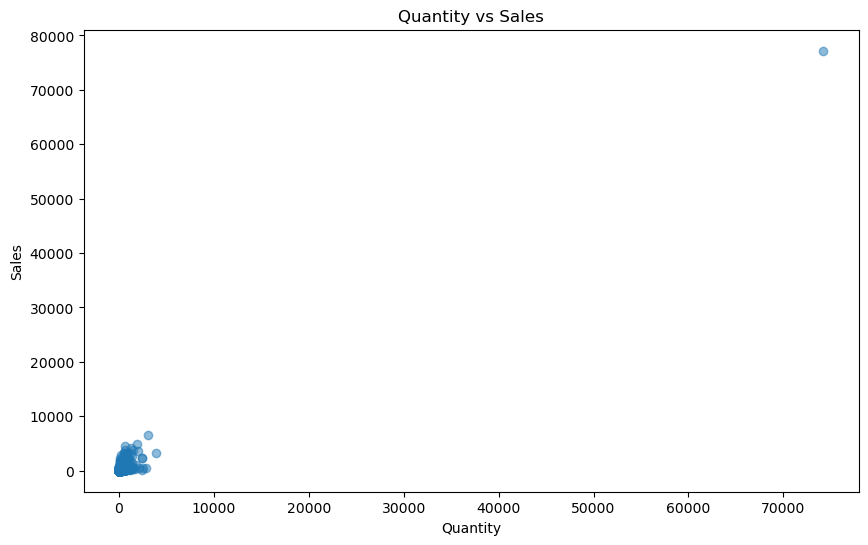

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_filtered["Quantity"],
    df_filtered["Sales"],
    alpha=0.5
)

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")

plt.show()

In [22]:
df_filtered = df_merged[df_merged["Quantity"] != 0
].copy()
display(df_filtered.head())

In [21]:
df_merged.describe()

,InvoiceNo,StockCode,Quantity,UnitPrice,Sales
count,83277.000000,83277.000000,83277.000000,83277.000000,83277.000000
mean,550244.000000,32948.774860,13.610961,3.083503,23.121043
std,8013.381169,22938.831323,261.577565,5.177653,278.041319
min,536365.000000,10002.000000,1.000000,0.000000,0.000000
25%,543304.000000,21843.000000,2.000000,1.250000,5.000000
50%,550244.000000,22470.000000,6.000000,1.950000,12.500000
75%,557184.000000,22941.000000,12.000000,3.750000,19.500000
max,564123.000000,90214.000000,74215.000000,295.000000,77183.600000


## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

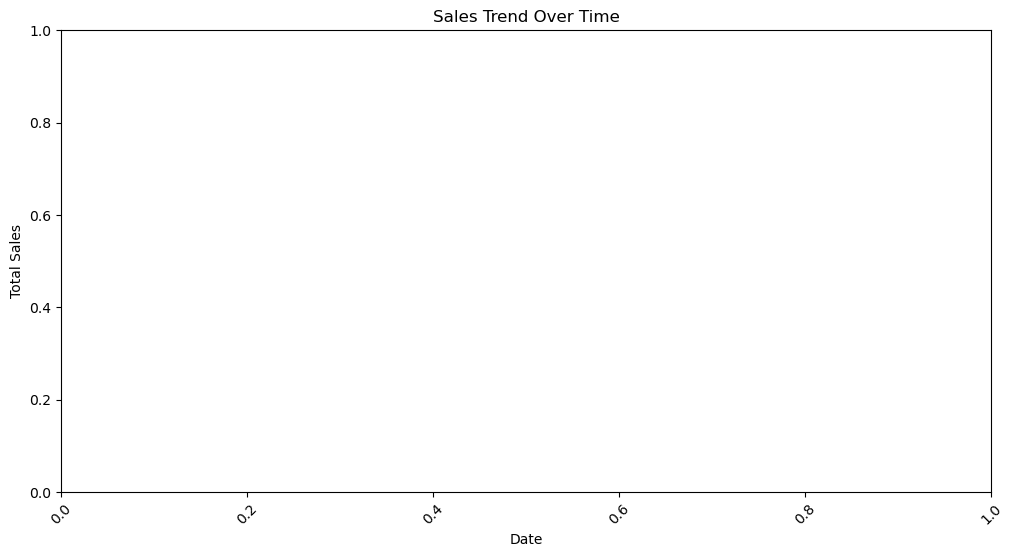

In [26]:
df_filtered["InvoiceDate"] = pd.to_datetime(
    df_filtered["InvoiceDate"]
)

daily_sales = df_filtered.groupby(
    df_filtered["InvoiceDate"].dt.date
)["Sales"].sum()

plt.figure(figsize=(12, 6))

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")

plt.xticks(rotation=45)

plt.show()

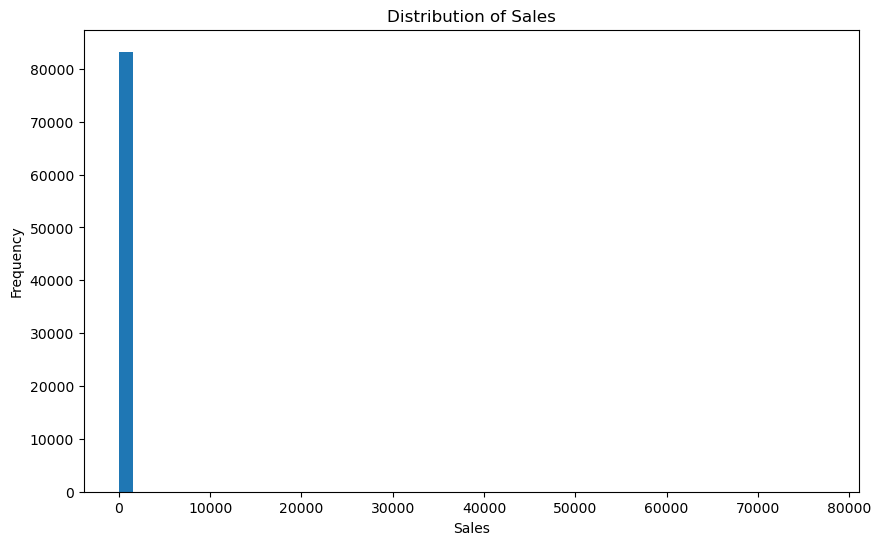

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_filtered["Sales"],
    bins=50
)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")

plt.show()

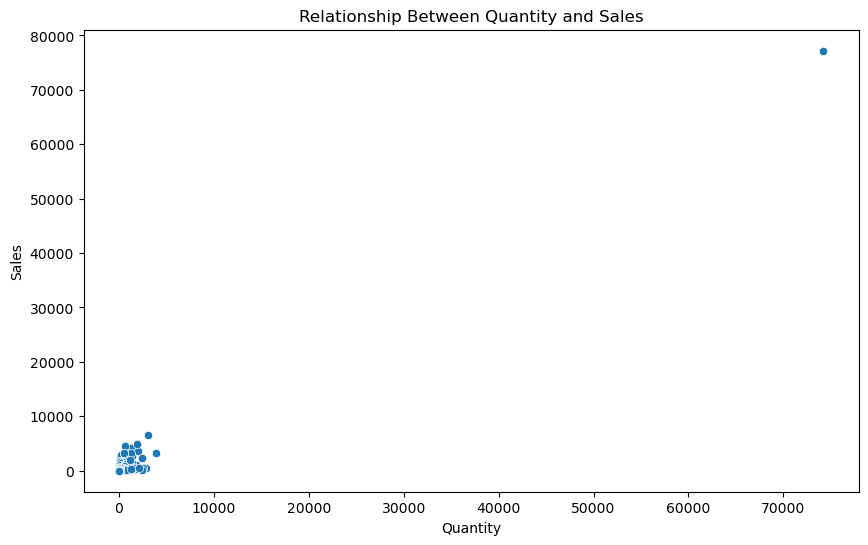

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_filtered,
    x="Quantity",
    y="Sales"
)

plt.title("Relationship Between Quantity and Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

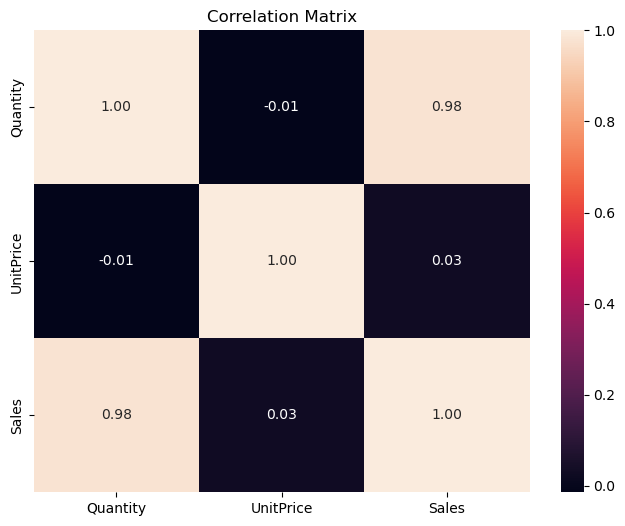

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [28]:
correlation_matrix = df_filtered[
    ["Quantity", "UnitPrice", "Sales"]
].corr()

display(correlation_matrix)

In [27]:
correlation = df_filtered["Quantity"].corr(
    df_filtered["Sales"]
)

print("Correlation between Quantity and Slaes", correlation)

Correlation between Quantity and Slaes 0.9786092498011646


## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [32]:
pivot_table = pd.pivot_table(
    df_merged,
    values="Sales",
    index="Country",
    columns="Product_Category",
    aggfunc="sum",
    fill_value=0
)

display(pivot_table)

In [30]:
category_sales = df_merged.groupby(
    "Product_Category"
)["Sales"].sum().sort_values(
    ascending=False
)

display(category_sales)

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Please write 1-2 sentences for task 5 and task 6. Moreover, please fix on of the graphs of task 5